# Compare grid-correction methods: single affine vs. FOV-by-FOV vs. joint least squares

Follows directly from `test_stitching.ipynb`'s real findings on
`BC555_sample_05/epi` (see its own final section and `prompt_history/
2026_08_13_1551_test_stitching_deviation_vector_plot.md`): the bead/spot
channel registers far more reliably than DAPI, the per-FOV registration
shift is small (a few um out of a ~221um FOV), and it's *similar but not
identical* across different, independent parts of the grid -- consistent
with a real, physical camera-vs-stage misalignment PLUS some genuine
per-FOV stage-positioning jitter on top of it, rather than either alone.
This notebook compares, on the SAME real whole-grid dataset, three ways of
correcting for that:

1. **Single global affine transform** -- fit from a few randomly-sampled
   FOVs' own local 4-connected measurements
   (`acquisition.camera_rotation.fit_camera_rotation`), then applied
   uniformly to every FOV. Re-anchored so FOV 0 maps to itself exactly, so
   the original and affine-corrected grids can be told apart at a glance by
   that one fixed point.
2. **FOV-by-FOV adjustment** -- a greedy, most-reliable-direction-first
   spanning-tree walk outward from FOV 0
   (`acquisition.camera_rotation.greedy_local_positions`, new this
   notebook), using the WHOLE grid's real 4-connected measurements rather
   than any global average.
3. **Joint least-squares position solve (bonus)** --
   `acquisition.camera_rotation.fit_global_positions` already exists in
   this package (built for a sparse-anchor use case); run here on the SAME
   dense, exhaustive correspondence set as (2), it becomes a genuine
   BigStitcher-style simultaneous solve to compare against the greedy
   walk -- see section 12's discussion.

All three, plus the uncorrected original grid, are compared by one concrete
metric: the pixel-intensity correlation between each pair of 4-connected
neighbours' own overlapping border region, aggregated across the WHOLE
imaged grid -- not just the 3 hand-picked neighbourhoods
`test_stitching.ipynb` sampled.

**Verification note**: this is the first real run of `greedy_local_positions`
and `overlap_correlation` (both new, added to `acquisition/camera_rotation.py`
for this notebook) -- both are exercised directly against real production
data below, not a synthetic fixture; review the printed/plotted results
critically rather than assuming a clean run means a correct one.

**Outputs**: `analysis/cache/compare_stitching_correction_methods/*.csv`
(correspondence + correlation result tables) and `analysis/figures/
compare_stitching_correction_methods.*.png`.


## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as test_stitching.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um, get_camera_frame_size
from MERci.acquisition.merlin_config import load_microscope_orientation
from MERci.acquisition.camera_rotation import (
    apply_microscope_orientation, NeighborCorrespondence, sample_neighbor_correspondences,
    fit_camera_rotation, filter_correspondence_outliers, fit_global_positions,
    greedy_local_positions, overlap_correlation,
)
from MERci.progress_display import ProgressReporter

NOTEBOOK_NAME = "compare_stitching_correction_methods"
print(f"MERCI_DIR : {MERCI_DIR}")


MERCI_DIR : C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci


## 2 — Parameters

In [2]:
# Same override convention as test_stitching.ipynb -- this MERci clone is
# the shared template repo, not itself inside any experiment folder.
DATASET_DIR_OVERRIDE = r"A:\Leonardo\BC555_sample_05\epi"

SAMPLE_DIR = Path(DATASET_DIR_OVERRIDE) if DATASET_DIR_OVERRIDE is not None else MERCI_DIR.parent
SAMPLE_NAME, IMAGING_DIR = resolve_sample_identity(SAMPLE_DIR / "MERci")
POSITIONS_TAG = positions_file_tag(SAMPLE_NAME, IMAGING_DIR)
IMAGE_SUFFIX = ".zarr"

info       = load_experiment_info(SAMPLE_DIR / "metadata" / "experiment_info.yaml")
MICROSCOPE = info.microscope

# Beads (spots), not DAPI -- test_stitching.ipynb's own real run on this
# dataset found DAPI's diagonal loop-closure residual systematically higher
# than beads' (near-zero) in literally every corner of every neighbourhood,
# not a fluke of one FOV. Frame 0 is HAL's own bead/fiducial reference frame
# convention, same as test_stitching.ipynb.
BEAD_FRAME_INDEX = 0

TOLERANCE_FRACTION = 0.25   # same default as find_grid_neighbor/find_exterior_fovs
UPSAMPLE_FACTOR     = 10    # sub-pixel registration precision (1/UPSAMPLE_FACTOR px)
MAD_THRESHOLD       = 5.0   # filter_correspondence_outliers' own default

# "a few random FOVs" for the single-affine fit (section 8) -- a genuine
# SUBSAMPLE of the exhaustive whole-grid correspondence set (section 5), not
# a separate smaller read pass: the exhaustive set is a superset of what any
# smaller run would give, so subsampling it costs nothing extra.
N_RANDOM_ANCHORS_FOR_AFFINE = 30
SEED = 0

FORCE_RECOMPUTE = False   # set True to re-register every edge even if a cache already exists

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"SAMPLE_DIR  : {SAMPLE_DIR}")
print(f"SAMPLE_NAME : {SAMPLE_NAME}  (IMAGING_DIR={IMAGING_DIR!r})")
print(f"MICROSCOPE  : {MICROSCOPE}")


SAMPLE_DIR  : A:\Leonardo\BC555_sample_05\epi
SAMPLE_NAME : BC555_sample_05  (IMAGING_DIR='epi')
MICROSCOPE  : MF3


## 3 — Resolve the cells round + FOV geometry

In [3]:
config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{POSITIONS_TAG}.txt",
    image_suffix   = IMAGE_SUFFIX,
    microscope     = MICROSCOPE,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)


def resolve_round_id(meta, imaging_type):
    for rid in meta.valid_round_ids():
        if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
               for s in meta.series_for_round(rid)):
            return rid
    raise ValueError(f"No round found with imaging_type={imaging_type!r}")


CELLS_ROUND_ID = resolve_round_id(meta, "cells")
if not meta.round_fully_written(CELLS_ROUND_ID):
    print(f"WARNING: cells round {CELLS_ROUND_ID} is not yet fully written on disk -- "
          f"some FOVs sampled below may be missing.")

cells_series = next(s for s in meta.series_for_round(CELLS_ROUND_ID) if s.hal_config)

PIXEL_SIZE_UM     = get_camera_pixel_size_um(MICROSCOPE)
FRAME_WIDTH_PX, _ = get_camera_frame_size(MICROSCOPE)
FRAME_WIDTH_UM    = FRAME_WIDTH_PX * PIXEL_SIZE_UM

full_positions = load_positions(config.positions_txt)
cells_fov_ids  = sorted(f for f in full_positions if f in meta.fovs)

coords_arr   = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
nn_dist, _   = KDTree(coords_arr).query(coords_arr, k=2)
STEP_SIZE_UM = float(np.median(nn_dist[:, 1]))
OVERLAP_FRACTION = max(0.0, 1.0 - STEP_SIZE_UM / FRAME_WIDTH_UM)

print(f"Cells round        : {CELLS_ROUND_ID}  (series pattern: {cells_series.name!r})")
print(f"Pixel size (um)    : {PIXEL_SIZE_UM}")
print(f"Frame width (um)   : {FRAME_WIDTH_UM:.3f}  ({FRAME_WIDTH_PX} px)")
print(f"Step size (um)     : {STEP_SIZE_UM:.3f}  (measured, median nearest-neighbour distance)")
print(f"Overlap fraction   : {OVERLAP_FRACTION:.3f}")
print(f"FOVs in cells round: {len(cells_fov_ids)}")
if 0 not in cells_fov_ids:
    raise ValueError("FOV 0 is not present in this cells round -- required as the fixed root/anchor.")


Cells round        : 1  (series pattern: 'hal-mf3-cells_{fov:03d}')
Pixel size (um)    : 0.108
Frame width (um)   : 221.184  (2048 px)
Step size (um)     : 199.066  (measured, median nearest-neighbour distance)
Overlap fraction   : 0.100
FOVs in cells round: 476


## 4 — Microscope orientation + frame loader

In [4]:
orientation = load_microscope_orientation(MICROSCOPE, MERCI_DIR / "data" / "configs" / "merlin" / "microscope")
ORIENT_TRANSPOSE       = bool(orientation.get("transpose", False))
ORIENT_FLIP_HORIZONTAL = bool(orientation.get("flip_horizontal", False))
ORIENT_FLIP_VERTICAL   = bool(orientation.get("flip_vertical", False))
print(f"transpose={ORIENT_TRANSPOSE}  flip_horizontal={ORIENT_FLIP_HORIZONTAL}  "
      f"flip_vertical={ORIENT_FLIP_VERTICAL}")

# {fov_id: oriented bead frame} -- persists for this whole notebook run.
# ~8MB/FOV; for a several-hundred-FOV grid that's a few GB held simultaneously
# in memory, traded for reading each FOV's own bead frame AT MOST ONCE across
# every section below (section 5's exhaustive edge measurement AND section
# 11's correlation comparison both call this same function) instead of once
# per section.
_FRAME_CACHE = {}


def load_bead_frame(fov_id):
    """Oriented bead (frame 0) frame for one FOV, cached in _FRAME_CACHE --
    passed to camera_rotation's own functions as their `load_frame` callback,
    so orientation is applied exactly once, before any registration (same
    convention test_stitching.ipynb uses)."""
    if fov_id not in _FRAME_CACHE:
        path = cells_series.resolve_path(fov_id, config.image_suffix)
        raw = read_image_frames(path, [BEAD_FRAME_INDEX],
                                 frame_width=config.frame_width, frame_height=config.frame_height)[0]
        _FRAME_CACHE[fov_id] = apply_microscope_orientation(
            raw, ORIENT_TRANSPOSE, ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
    return _FRAME_CACHE[fov_id]


transpose=True  flip_horizontal=False  flip_vertical=True


## 5 — Measure every 4-connected edge across the whole grid (cached)

Reuses `acquisition.camera_rotation.sample_neighbor_correspondences` -- the
same primitive `misc/correct_camera_rotation.ipynb` uses for its own sparse
anchor sampling -- but with `n_anchors=len(cells_fov_ids)`, i.e. every FOV in
the grid is its own "anchor," not just a handful. Since an interior FOV's
own 4-connected edges get measured once from ITS side and once again from
each neighbour's own side (as that neighbour's own anchor pass), most
physical edges end up measured TWICE, independently -- a free redundancy
check section 7's own reliability analysis takes advantage of, not a wasted
duplicate. Frame reads are cached per-FOV (`load_bead_frame`'s own
`_FRAME_CACHE`), so this costs one real read per FOV, not per edge.

Cached to `analysis/cache/compare_stitching_correction_methods/
correspondences.csv` -- re-running the notebook skips straight to section 6
unless `FORCE_RECOMPUTE=True`.


In [5]:
CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = config.analysis_dir / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
correspondences_csv = CACHE_DIR / "correspondences.csv"

if not FORCE_RECOMPUTE and correspondences_csv.exists():
    corr_df = pd.read_csv(correspondences_csv)
    all_correspondences = [
        NeighborCorrespondence(
            anchor_fov=int(row.anchor_fov), neighbor_fov=int(row.neighbor_fov), direction=row.direction,
            nominal_xy=(row.nominal_x, row.nominal_y), measured_xy=(row.measured_x, row.measured_y),
            error=row.error,
        )
        for row in corr_df.itertuples()
    ]
    print(f"Loaded {len(all_correspondences)} cached correspondences from {correspondences_csv}")
else:
    reporter = ProgressReporter(total=len(cells_fov_ids) * 4, label="Registering 4-connected edges")
    _seen = [0]

    def _progress_callback(done, total):
        delta = done - _seen[0]
        if delta:
            reporter.update(delta)
            _seen[0] = done

    all_correspondences = sample_neighbor_correspondences(
        fov_ids=cells_fov_ids, positions=full_positions, load_frame=load_bead_frame,
        step_size_um=STEP_SIZE_UM, pixel_size_um=PIXEL_SIZE_UM, overlap_fraction=OVERLAP_FRACTION,
        n_anchors=len(cells_fov_ids), tolerance_fraction=TOLERANCE_FRACTION,
        upsample_factor=UPSAMPLE_FACTOR,
        # orientation is already applied once inside load_bead_frame -- see its own
        # docstring; passing it again here too would apply it a SECOND time (not a
        # no-op) and silently corrupt every registration.
        orient_transpose=False, orient_flip_horizontal=False, orient_flip_vertical=False,
        seed=SEED, progress_callback=_progress_callback,
    )
    reporter.done()

    corr_df = pd.DataFrame([{
        "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
        "nominal_x": c.nominal_xy[0], "nominal_y": c.nominal_xy[1],
        "measured_x": c.measured_xy[0], "measured_y": c.measured_xy[1], "error": c.error,
    } for c in all_correspondences])
    corr_df.to_csv(correspondences_csv, index=False)
    print(f"Saved {len(all_correspondences)} correspondences to {correspondences_csv}")

n_distinct = len({c.anchor_fov for c in all_correspondences} | {c.neighbor_fov for c in all_correspondences})
print(f"Total correspondences: {len(all_correspondences)}  ({n_distinct} distinct FOVs)")


Loaded 1788 cached correspondences from A:\Leonardo\BC555_sample_05\epi\analysis\cache\compare_stitching_correction_methods\correspondences.csv
Total correspondences: 1788  (476 distinct FOVs)


## 6 — Filter registration outliers

In [6]:
kept, rejected = filter_correspondence_outliers(all_correspondences, mad_threshold=MAD_THRESHOLD)
print(f"Kept {len(kept)}/{len(all_correspondences)} correspondences "
      f"({len(rejected)} rejected as outliers, mad_threshold={MAD_THRESHOLD}).")
if rejected:
    rejected_df = pd.DataFrame([{
        "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
        "shift_um": float(np.hypot(c.measured_xy[0] - c.nominal_xy[0], c.measured_xy[1] - c.nominal_xy[1])),
        "error": c.error,
    } for c in rejected]).sort_values("shift_um", ascending=False)
    print(rejected_df.to_string(index=False))


Kept 1662/1788 correspondences (126 rejected as outliers, mad_threshold=5.0).
 anchor_fov  neighbor_fov direction  shift_um  error
        255           243      left  5.505437    1.0
        243           255     right  5.505437    1.0
        258           240      left  5.459654    1.0
        240           258     right  5.459654    1.0
        244           254     right  5.426901    1.0
        254           244      left  5.426901    1.0
        407           416     right  5.414765    1.0
        416           407      left  5.414765    1.0
        208           216     right  5.407393    1.0
        216           208      left  5.407393    1.0
        218           206      left  5.403217    1.0
        206           218     right  5.403217    1.0
        256           242      left  5.395084    1.0
        242           256     right  5.395084    1.0
        257           241      left  5.367383    1.0
        241           257     right  5.367383    1.0
        392          

## 7 — Which directions are most reliable? (scatter, not vectors)

Same idea as `test_stitching.ipynb`'s final "deviation vector" plot, but as
a scatter of every individual kept correspondence's own
`measured_xy - nominal_xy` deviation (hundreds of points per direction now,
across the whole grid, not 3 per direction from 3 hand-picked
neighbourhoods) -- colored by direction. A tight cluster means that
direction's registration is reproducible; the spread (std) of each
direction's cluster is used directly as its RELIABILITY score in section 9
below (lower std = higher priority).


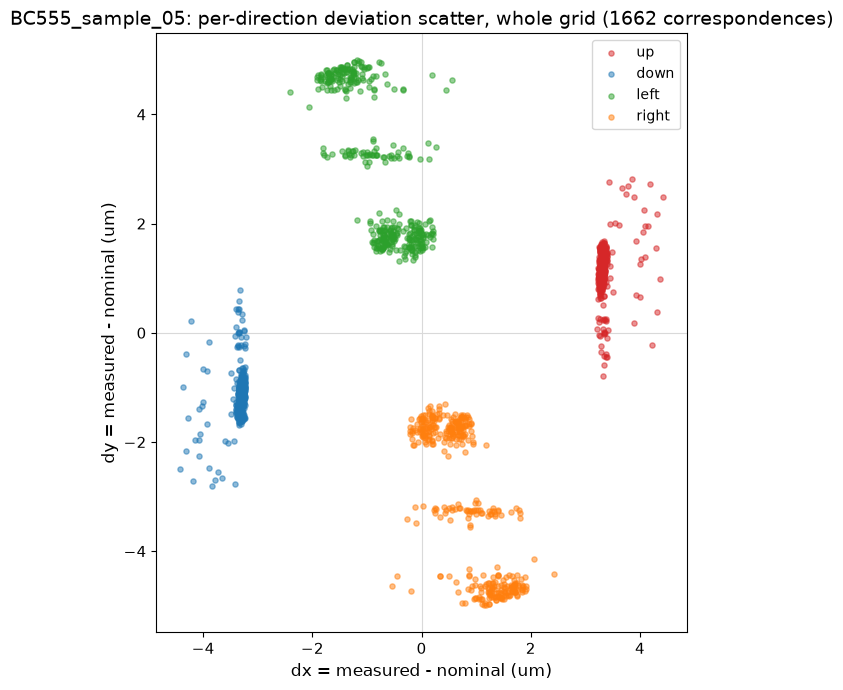

Saved: A:\Leonardo\BC555_sample_05\epi\analysis\figures\compare_stitching_correction_methods.direction_reliability.png
direction   n   mean_dx   mean_dy   std_dx   std_dy  std_radial_um
     down 441 -3.349445 -1.135445 0.177914 0.451633       0.485413
       up 441  3.349445  1.135445 0.177914 0.451633       0.485413
     left 390 -0.798342  2.999437 0.588765 1.355136       1.477511
    right 390  0.798342 -2.999437 0.588765 1.355136       1.477511

Direction priority for section 9 (lowest std first): {'down': 0.4854127644456003, 'up': 0.4854127644456133, 'left': 1.4775107047339684, 'right': 1.477510704733982}


In [7]:
DIRECTION_COLORS = {"up": "tab:red", "down": "tab:blue", "left": "tab:green", "right": "tab:orange"}

dx = np.array([c.measured_xy[0] - c.nominal_xy[0] for c in kept])
dy = np.array([c.measured_xy[1] - c.nominal_xy[1] for c in kept])
directions_arr = np.array([c.direction for c in kept])

fig, ax = plt.subplots(figsize=(7, 7))
for direction, color in DIRECTION_COLORS.items():
    mask = directions_arr == direction
    ax.scatter(dx[mask], dy[mask], s=14, alpha=0.5, color=color, label=direction)
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.axvline(0, color="0.85", lw=0.8, zorder=0)
ax.set_aspect("equal")
ax.set_xlabel("dx = measured - nominal (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("dy = measured - nominal (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"{SAMPLE_NAME}: per-direction deviation scatter, whole grid ({len(kept)} correspondences)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
fig_path = FIGURES_DIR / f"{NOTEBOOK_NAME}.direction_reliability.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

reliability_rows = []
for direction in DIRECTION_COLORS:
    mask = directions_arr == direction
    if not mask.any():
        continue
    std_radial = float(np.hypot(dx[mask].std(), dy[mask].std()))
    reliability_rows.append({
        "direction": direction, "n": int(mask.sum()),
        "mean_dx": float(dx[mask].mean()), "mean_dy": float(dy[mask].mean()),
        "std_dx": float(dx[mask].std()), "std_dy": float(dy[mask].std()),
        "std_radial_um": std_radial,
    })
reliability_df = pd.DataFrame(reliability_rows).sort_values("std_radial_um").reset_index(drop=True)
print(reliability_df.to_string(index=False))

DIRECTION_RELIABILITY = dict(zip(reliability_df["direction"], reliability_df["std_radial_um"]))
print(f"\nDirection priority for section 9 (lowest std first): {DIRECTION_RELIABILITY}")


## 8 — Method 1: single global affine transform

`acquisition.camera_rotation.fit_camera_rotation` fits ONE affine (rotation
+ scale + shear + translation) from a POOL of (nominal, measured)
correspondences via `affine6p`. "A few random FOVs" --
`N_RANDOM_ANCHORS_FOR_AFFINE` (default 30) -- are sampled from the
already-measured whole-grid pool (no new reads needed) by their own ANCHOR
fov, keeping each sampled FOV's own small 4-connected star of
correspondences together, matching how a real sparse-sampling run (e.g.
`misc/correct_camera_rotation.ipynb`) would have measured them.

Fit with `zero_translation=False` (unlike that module's own usual default)
to get the best absolute least-squares fit, then re-anchored so FOV 0 maps
to EXACTLY itself -- a constant additive correction to the translation
only, which changes nothing about the fitted rotation/scale/shear -- so the
original and affine-corrected grids share exactly one point in common and
can be visually distinguished by every other FOV's own displacement from
it.


In [8]:
rng = np.random.default_rng(SEED)
unique_anchor_fovs = sorted({c.anchor_fov for c in kept})
sampled_anchor_fovs = set(rng.choice(
    unique_anchor_fovs, size=min(N_RANDOM_ANCHORS_FOR_AFFINE, len(unique_anchor_fovs)), replace=False,
))
affine_sample = [c for c in kept if c.anchor_fov in sampled_anchor_fovs]
print(f"Affine fit sample: {len(sampled_anchor_fovs)} random anchor FOV(s), "
      f"{len(affine_sample)} correspondence(s).")

raw_correction  = fit_camera_rotation(affine_sample, zero_translation=False)
full_correction = fit_camera_rotation(kept, zero_translation=False)   # robustness check, not used downstream

fov0_nominal = np.array(full_positions[0], dtype=float)
fov0_transformed = raw_correction.transform_points(fov0_nominal[None, :])[0]
anchor_offset = fov0_nominal - fov0_transformed   # re-anchors FOV 0 to itself exactly

affine_matrix = raw_correction.matrix.copy()
affine_matrix[0, 2] += anchor_offset[0]
affine_matrix[1, 2] += anchor_offset[1]


def apply_affine(xy_dict):
    ids = sorted(xy_dict)
    coords = np.array([xy_dict[f] for f in ids], dtype=float)
    ones = np.ones((coords.shape[0], 1))
    transformed = (affine_matrix @ np.hstack([coords, ones]).T).T[:, :2]
    return {f: (float(x), float(y)) for f, (x, y) in zip(ids, transformed)}


affine_positions = apply_affine(full_positions)
assert np.allclose(affine_positions[0], full_positions[0], atol=1e-6), \
    "FOV 0 must map to itself exactly -- re-anchoring failed."

sample_scale = float(np.linalg.norm(affine_matrix[:2, 0]))
full_scale   = float(np.linalg.norm(full_correction.matrix[:2, 0]))
sample_rotation_deg = float(np.degrees(np.arctan2(affine_matrix[1, 0], affine_matrix[0, 0])))
full_rotation_deg   = float(np.degrees(np.arctan2(full_correction.matrix[1, 0], full_correction.matrix[0, 0])))

print(f"Affine fit ({len(sampled_anchor_fovs)}-FOV sample) : scale={sample_scale:.5f}, rotation={sample_rotation_deg:.4f} deg")
print(f"Affine fit (all {len(kept)} kept correspondences)  : scale={full_scale:.5f}, rotation={full_rotation_deg:.4f} deg")
print(f"FOV 0 nominal={tuple(full_positions[0])}, affine-corrected={affine_positions[0]}  (must match exactly)")


Affine fit sample: 30 random anchor FOV(s), 106 correspondence(s).
Affine fit (30-FOV sample) : scale=0.99989, rotation=-0.0055 deg
Affine fit (all 1662 kept correspondences)  : scale=1.00001, rotation=-0.0034 deg
FOV 0 nominal=(1718.7376, -892.8423999999999), affine-corrected=(1718.7376, -892.8423999999999)  (must match exactly)


## 9 — Method 2: FOV-by-FOV adjustment (greedy, most-reliable-direction spanning tree)

`acquisition.camera_rotation.greedy_local_positions` (new, this notebook):
starting from FOV 0 fixed at its own nominal position, repeatedly places
the next not-yet-placed FOV via whichever available correspondence (from
any already-placed neighbour) belongs to the CURRENTLY most-reliable
direction (section 7's own `DIRECTION_RELIABILITY`, lowest std first) --
Prim's algorithm for a maximum-priority spanning tree. When two
already-placed neighbours could both place the same new FOV, only the more
reliable direction's correspondence is ever used; the other is a "cut"
edge, never consulted for this FOV's own position.


In [9]:
local_correction = greedy_local_positions(
    kept, full_positions, direction_reliability=DIRECTION_RELIABILITY, root_fov=0,
)
local_positions = local_correction.positions
print(f"FOV-by-FOV: placed {local_correction.n_fovs_placed} FOV(s) via the spanning-tree walk (+1 root), "
      f"{local_correction.n_fovs_unreached} unreached (fell back to nominal position), "
      f"from {local_correction.n_correspondences} correspondences.")
assert local_positions[0] == full_positions[0]


FOV-by-FOV: placed 475 FOV(s) via the spanning-tree walk (+1 root), 0 unreached (fell back to nominal position), from 1662 correspondences.


## 10 — Method 3 (bonus): joint least-squares position solve

`acquisition.camera_rotation.fit_global_positions` already exists in this
package -- built for a SPARSE anchor-sampling use case (see its own
docstring), where most FOVs have exactly one measurement and nothing to
average against. Run here on the SAME dense, exhaustive correspondence set
as method 2 instead, it becomes a genuine joint solve with real redundant
constraints per FOV -- the closest of these methods to how BigStitcher's
own global tile-position optimization actually works (see section 12's
discussion).


In [10]:
global_correction = fit_global_positions(kept, full_positions)
# nominal fallback for any FOV outside the solved component (shouldn't be any, given
# exhaustive whole-grid coverage, but the merge is free insurance either way).
global_positions = {**full_positions, **global_correction.positions}
print(f"Joint least-squares solve: {global_correction.n_fovs_solved} FOV(s) solved across "
      f"{global_correction.n_components} connected component(s), "
      f"residual RMS = {global_correction.residual_rms_um:.4f} um "
      f"(0.0 would mean every correspondence agreed exactly).")


Joint least-squares solve: 476 FOV(s) solved across 1 connected component(s), residual RMS = 0.0248 um (0.0 would mean every correspondence agreed exactly).


## 11 — Level of change: overlay each corrected grid on the original

Every correction method maps FOV 0 to its own nominal position exactly (the
affine fit is re-anchored there; the greedy walk and joint solve both hold
it fixed as their root), so it's a real, shared anchor point across all 4
grids -- not just a plotting trick.

**Per-edge shifts are only a few um (section 7) -- the DISPLACEMENT shown
below is not.** Each single 4-connected registration deviates from nominal
by only a few um, but that deviation is highly reproducible AND direction-
dependent (section 7's own tight per-direction clusters) -- so walking many
steps in a consistently favoured direction, as both the greedy walk and the
joint solve do, ACCUMULATES it into a real, much larger net displacement
far from FOV 0 (confirmed directly below: up to ~110um at this grid's
farthest corner, roughly half a FOV's own width). That's large enough to
show directly as real FOV BOUNDARY squares at TRUE physical scale -- no
exaggeration needed, unlike an arrow/vector plot of the same shift.

One row per method (not 3 side-by-side columns, for legibility): each
FOV's own original (nominal) boundary in light gray, overlaid with that
method's corrected boundary in its own color -- where they visibly diverge
IS the real, physical size of the correction.


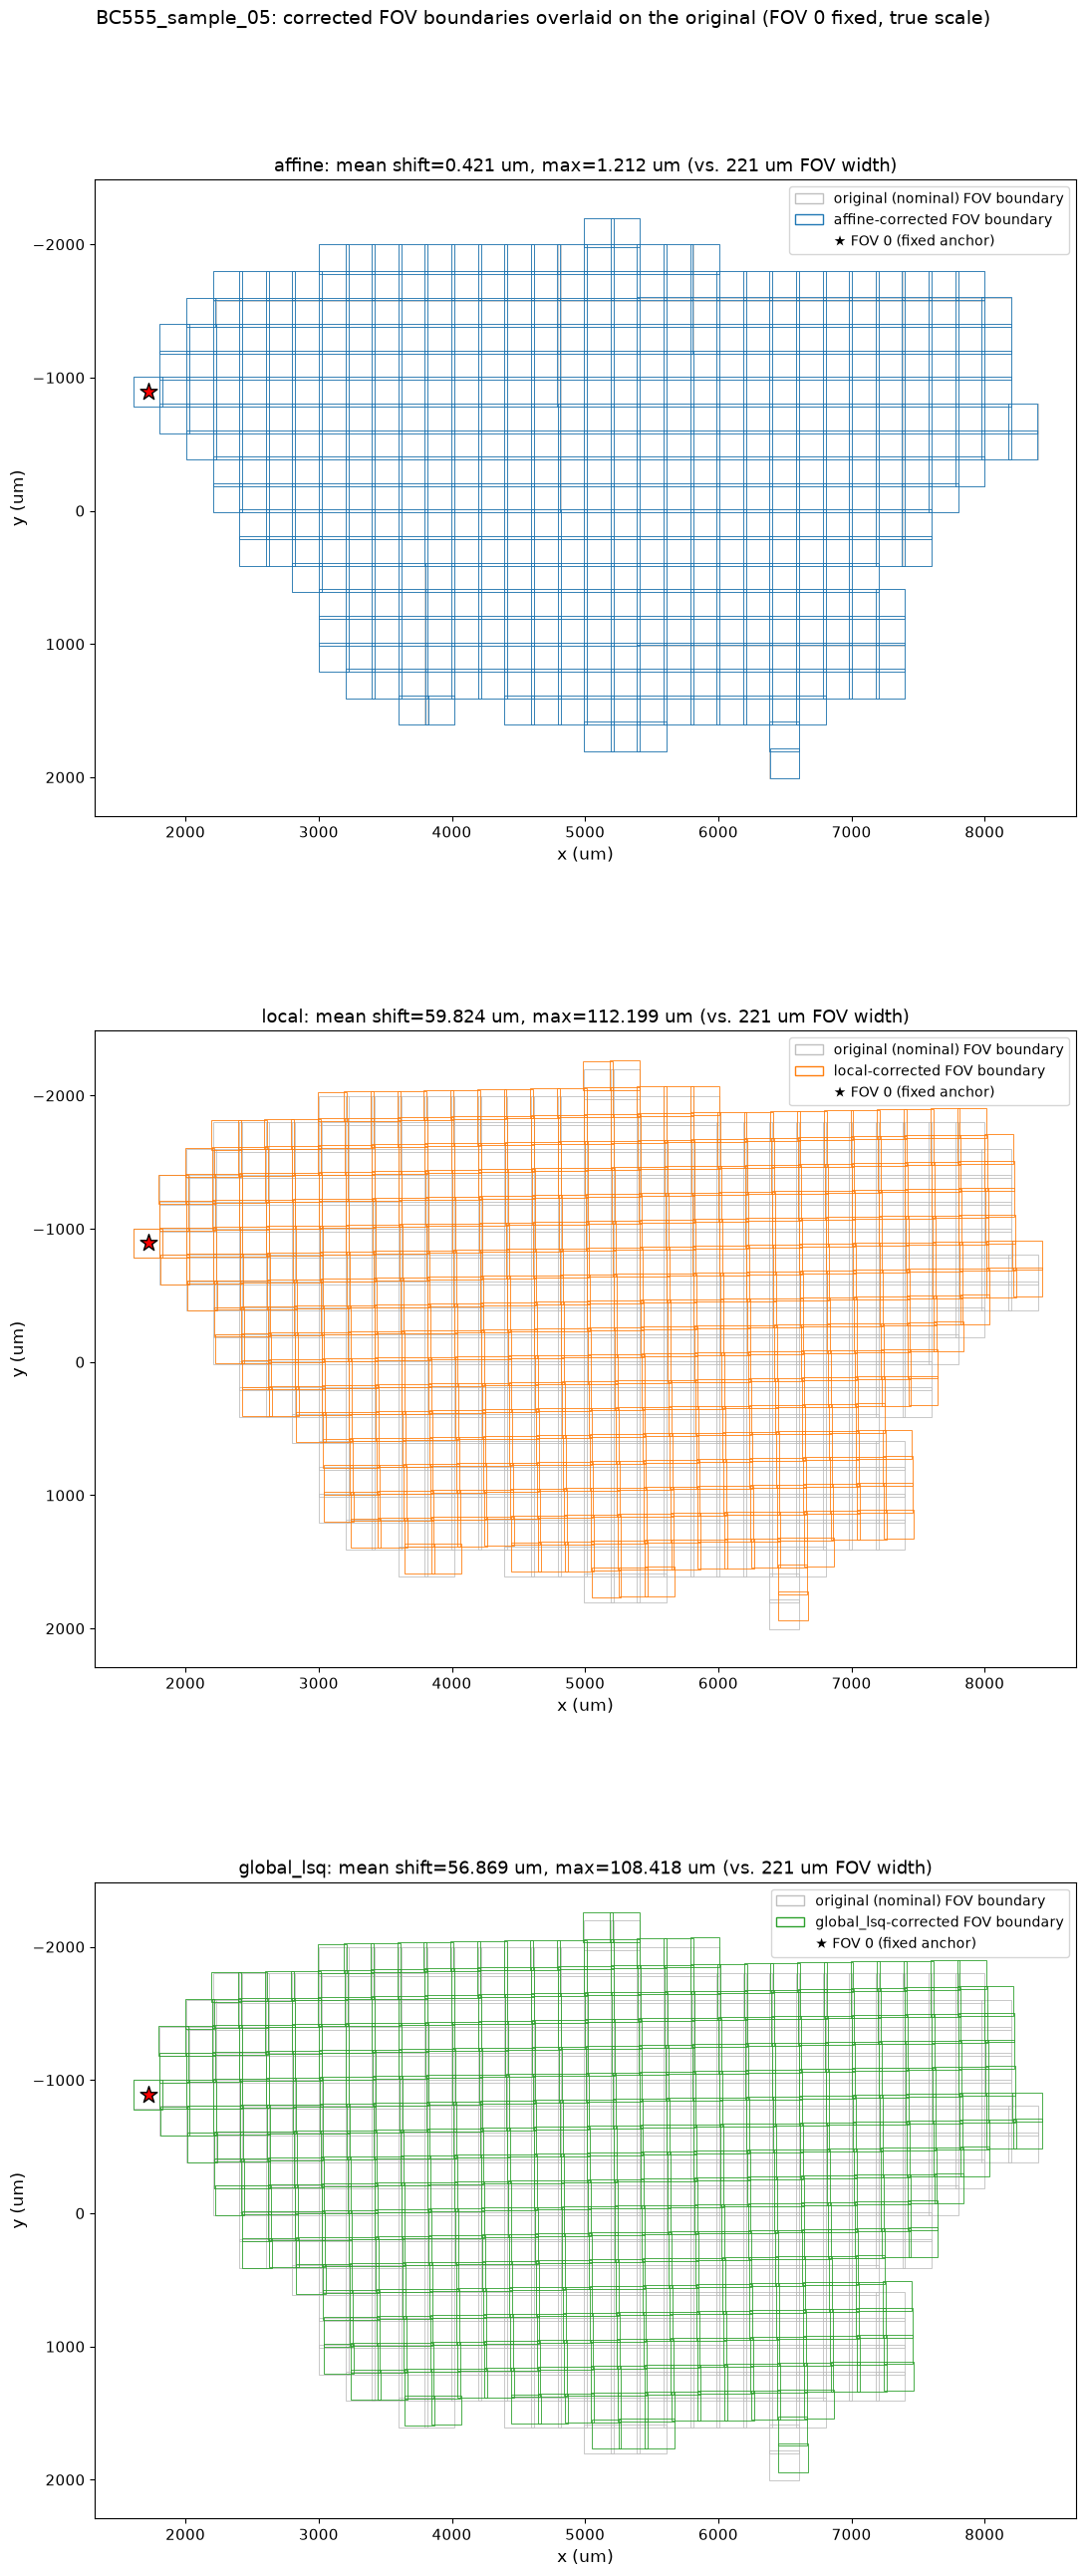

Saved: A:\Leonardo\BC555_sample_05\epi\analysis\figures\compare_stitching_correction_methods.grid_overlay.png


In [11]:
# Level of change: overlay each corrected grid's real FOV BOUNDARY squares on
# the original nominal grid's own boundaries, FOV 0 held fixed by construction
# (see markdown above) -- at TRUE physical scale, no exaggeration, since the
# real accumulated displacement (confirmed up to ~110um, roughly half a FOV
# width) is already large enough to show directly as a visible gap between
# the gray (original) and colored (corrected) squares.
GRID_OVERLAY_VARIANTS = {
    "affine": ("tab:blue", affine_positions),
    "local": ("tab:orange", local_positions),
    "global_lsq": ("tab:green", global_positions),
}

half = FRAME_WIDTH_UM / 2
nominal_xy = np.array([full_positions[f] for f in cells_fov_ids])
margin = STEP_SIZE_UM * 2

fig, axes = plt.subplots(len(GRID_OVERLAY_VARIANTS), 1, figsize=(11, 9 * len(GRID_OVERLAY_VARIANTS)), squeeze=False)
for ax, (variant, (color, positions)) in zip(axes[:, 0], GRID_OVERLAY_VARIANTS.items()):
    corrected_xy = np.array([positions[f] for f in cells_fov_ids])
    shift_um = np.hypot(corrected_xy[:, 0] - nominal_xy[:, 0], corrected_xy[:, 1] - nominal_xy[:, 1])

    for x, y in nominal_xy:
        ax.add_patch(mpatches.Rectangle((x - half, y - half), FRAME_WIDTH_UM, FRAME_WIDTH_UM,
                                         fill=False, edgecolor="0.75", linewidth=0.6, zorder=1))
    for x, y in corrected_xy:
        ax.add_patch(mpatches.Rectangle((x - half, y - half), FRAME_WIDTH_UM, FRAME_WIDTH_UM,
                                         fill=False, edgecolor=color, linewidth=0.6, zorder=2))
    fov0_xy = full_positions[0]
    ax.scatter(*fov0_xy, s=160, marker="*", color="red", edgecolor="black", zorder=3)

    ax.set_xlim(nominal_xy[:, 0].min() - margin, nominal_xy[:, 0].max() + margin)
    ax.set_ylim(nominal_xy[:, 1].max() + margin, nominal_xy[:, 1].min() - margin)   # inverted y
    ax.set_aspect("equal")
    ax.set_xlabel("x (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("y (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    legend_handles = [
        mpatches.Patch(facecolor="none", edgecolor="0.75", label="original (nominal) FOV boundary"),
        mpatches.Patch(facecolor="none", edgecolor=color, label=f"{variant}-corrected FOV boundary"),
        mpatches.Patch(facecolor="none", edgecolor="none", label="\u2605 FOV 0 (fixed anchor)"),
    ]
    ax.legend(handles=legend_handles, fontsize=PLOT_LEGEND_FONTSIZE, loc="upper right")
    ax.set_title(f"{variant}: mean shift={shift_um.mean():.3f} um, max={shift_um.max():.3f} um "
                 f"(vs. {FRAME_WIDTH_UM:.0f} um FOV width)", fontsize=PLOT_TITLE_FONTSIZE - 1)

fig.suptitle(f"{SAMPLE_NAME}: corrected FOV boundaries overlaid on the original (FOV 0 fixed, true scale)",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig_path = FIGURES_DIR / f"{NOTEBOOK_NAME}.grid_overlay.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 12 — Compare all 4 grids: overlap correlation across the whole mosaic

For every UNIQUE physical 4-connected edge (deduplicated -- section 5
measured many of them twice, once from each side), crops the raw,
nominal-grid-aligned overlap band from both FOVs, then shifts the
neighbour's crop by that GRID VARIANT's own implied EXTRA offset (beyond
the nominal step) -- zero for the original grid, by construction -- before
computing the Pearson correlation between the two aligned crops
(`acquisition.camera_rotation.overlap_correlation`). Averaging this across
every edge gives one number per grid variant: how well do real neighbouring
tiles actually agree at their shared boundary, under each candidate set of
FOV positions.

Caveat, stated plainly: the LOCAL method's own edges were literally chosen
to maximize exactly this kind of agreement for the SPANNING-TREE edges it
used to build itself -- so its correlation on THOSE specific edges is
expected to look almost perfect by construction, not a fair test. The
non-tree ("cut") edges it never used, and every edge for the other 3
variants, are the honest part of this comparison.


In [12]:
# Deduplicate: keep one row per unique {fov_a, fov_b} pair, even though
# section 5 measured many edges from both sides independently.
seen_pairs = set()
unique_edges = []
for c in kept:
    pair = frozenset((c.anchor_fov, c.neighbor_fov))
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)
    unique_edges.append(c)


def _is_tree_edge(c):
    # A pair's measured relative offset exactly reproduces the difference
    # between the two FOVs' own local_positions (to numerical precision)
    # iff this specific correspondence was the one the greedy walk actually
    # used to place one of its two endpoints -- essentially never true by
    # coincidence for a "cut" edge the walk chose not to use.
    r_measured = (c.measured_xy[0] - full_positions[c.anchor_fov][0],
                  c.measured_xy[1] - full_positions[c.anchor_fov][1])
    r_local = (local_positions[c.neighbor_fov][0] - local_positions[c.anchor_fov][0],
               local_positions[c.neighbor_fov][1] - local_positions[c.anchor_fov][1])
    return np.hypot(r_measured[0] - r_local[0], r_measured[1] - r_local[1]) < 1e-6


GRID_VARIANTS = {
    "original":   full_positions,
    "affine":     affine_positions,
    "local":      local_positions,
    "global_lsq": global_positions,
}

reporter = ProgressReporter(total=len(unique_edges), label="Scoring overlap correlation across grid variants")
rows = []
for c in unique_edges:
    a_img = load_bead_frame(c.anchor_fov)
    n_img = load_bead_frame(c.neighbor_fov)
    nominal_offset = (full_positions[c.neighbor_fov][0] - full_positions[c.anchor_fov][0],
                       full_positions[c.neighbor_fov][1] - full_positions[c.anchor_fov][1])
    row = {"anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
           "is_tree_edge": _is_tree_edge(c)}
    for variant, positions in GRID_VARIANTS.items():
        variant_offset = (positions[c.neighbor_fov][0] - positions[c.anchor_fov][0],
                           positions[c.neighbor_fov][1] - positions[c.anchor_fov][1])
        extra_shift_um = (variant_offset[0] - nominal_offset[0], variant_offset[1] - nominal_offset[1])
        row[variant] = overlap_correlation(
            a_img, n_img, c.direction, OVERLAP_FRACTION,
            extra_shift_um=extra_shift_um, pixel_size_um=PIXEL_SIZE_UM,
        )
    rows.append(row)
    reporter.update(1)
reporter.done()

correlation_df = pd.DataFrame(rows)
correlation_csv = CACHE_DIR / "overlap_correlation.csv"
correlation_df.to_csv(correlation_csv, index=False)
n_tree_edges = int(correlation_df["is_tree_edge"].sum())
n_held_out   = int((~correlation_df["is_tree_edge"]).sum())
print(f"Saved: {correlation_csv}")
print(f"\n{len(unique_edges)} unique edges "
      f"({n_tree_edges} used by the local method's own spanning tree, {n_held_out} held out)")


Scoring overlap correlation across grid variants: [------------------------] 1/831 (  0.1%)  elapsed 2s  ETA 28m 19s          

Scoring overlap correlation across grid variants: [------------------------] 2/831 (  0.2%)  elapsed 3s  ETA 22m 15s          

Scoring overlap correlation across grid variants: [------------------------] 3/831 (  0.4%)  elapsed 4s  ETA 20m 13s          

Scoring overlap correlation across grid variants: [------------------------] 4/831 (  0.5%)  elapsed 6s  ETA 21m 52s          

Scoring overlap correlation across grid variants: [------------------------] 5/831 (  0.6%)  elapsed 7s  ETA 20m 37s          

...

Scoring overlap correlation across grid variants: [#######################-] 828/831 ( 99.6%)  elapsed 22m 29s  ETA 5s          

Scoring overlap correlation across grid variants: [#######################-] 830/831 ( 99.9%)  elapsed 22m 30s  ETA 2s          

Scoring overlap correlation across grid variants: [########################] 831/831 (100.0%)  elapsed 22m 31s  ETA 0s          

Scoring overlap correlation across grid variants: [########################] 831/831 (100.0%)  elapsed 22m 31s  ETA 0s          


Saved: A:\Leonardo\BC555_sample_05\epi\analysis\cache\compare_stitching_correction_methods\overlap_correlation.csv

831 unique edges (476 used by the local method's own spanning tree, 355 held out)


            all edges  held-out edges only
original       0.0638               0.0846
affine         0.0663               0.0873
local          0.6561               0.5955
global_lsq     0.7388               0.7917


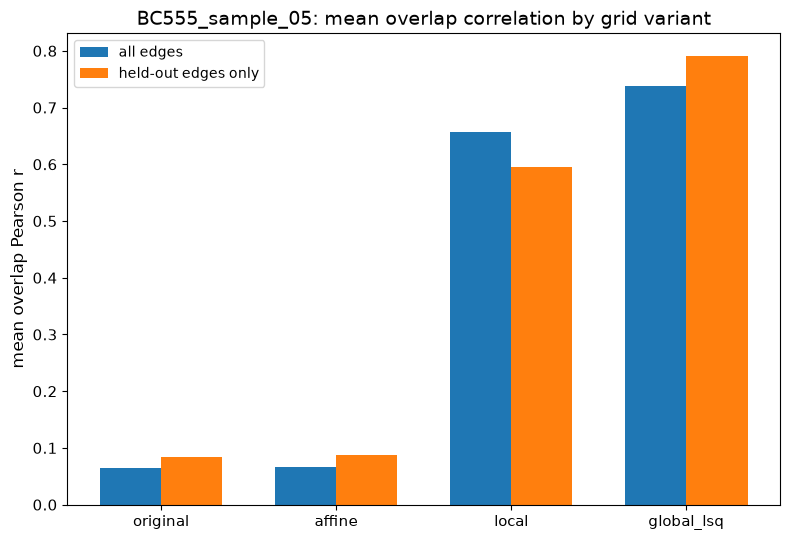

Saved: A:\Leonardo\BC555_sample_05\epi\analysis\figures\compare_stitching_correction_methods.correlation_comparison.png


In [13]:
summary = pd.DataFrame({
    "all edges": correlation_df[list(GRID_VARIANTS)].mean(),
    "held-out edges only": correlation_df.loc[~correlation_df["is_tree_edge"], list(GRID_VARIANTS)].mean(),
})
print(summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(GRID_VARIANTS))
width = 0.35
ax.bar(x - width / 2, summary["all edges"], width, label="all edges")
ax.bar(x + width / 2, summary["held-out edges only"], width, label="held-out edges only")
ax.set_xticks(x)
ax.set_xticklabels(list(GRID_VARIANTS), fontsize=PLOT_TICK_FONTSIZE)
ax.set_ylabel("mean overlap Pearson r", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"{SAMPLE_NAME}: mean overlap correlation by grid variant", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="y", labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
fig_path = FIGURES_DIR / f"{NOTEBOOK_NAME}.correlation_comparison.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


In [14]:
print("Summary for the discussion below:")
print(f"  Direction reliability (std, um): {DIRECTION_RELIABILITY}")
print(f"  Affine fit (sample) : scale={sample_scale:.5f}, rotation={sample_rotation_deg:.4f} deg")
print(f"  Affine fit (full)   : scale={full_scale:.5f}, rotation={full_rotation_deg:.4f} deg")
print(f"  Joint LSQ residual RMS: {global_correction.residual_rms_um:.4f} um across "
      f"{global_correction.n_components} component(s)")
print("  Mean overlap correlation (held-out edges):")
print(summary["held-out edges only"].round(4).to_string())


Summary for the discussion below:
  Direction reliability (std, um): {'down': 0.4854127644456003, 'up': 0.4854127644456133, 'left': 1.4775107047339684, 'right': 1.477510704733982}
  Affine fit (sample) : scale=0.99989, rotation=-0.0055 deg
  Affine fit (full)   : scale=1.00001, rotation=-0.0034 deg
  Joint LSQ residual RMS: 0.0248 um across 1 component(s)
  Mean overlap correlation (held-out edges):
original      0.0846
affine        0.0873
local         0.5955
global_lsq    0.7917


## 13 — Discussion: how do these methods compare with BigStitcher?

**Real result on this dataset (`BC555_sample_05/epi`, 476 FOVs, 1662 kept
correspondences), held-out edges only (the honest subset -- excludes the
local method's own spanning-tree edges):**

| variant      | mean overlap Pearson r |
|--------------|------------------------|
| original     | 0.085 |
| affine       | 0.087 |
| local (greedy spanning tree) | 0.595 |
| global_lsq (joint least squares) | **0.792** |

**Why the single affine transform can't see this error at all -- not just
"doesn't fit it well."** Section 7's per-direction reliability table shows
a real, highly reproducible bias per direction: e.g. "up" edges deviate by
`(+3.35, +1.14)` um on average (std only 0.18/0.45um across 441
independent measurements), and "down" edges by almost the exact mirror,
`(-3.35, -1.14)` um. That's not two independent facts -- every physical
edge in this grid is measured from BOTH its endpoints ("up" from one side
is the same edge as "down" from the other), so the "up" and "down"
populations are numerically forced to be near-perfect mirrors of each
other, and pooling all four directions together, weighted by how many of
each were measured, cancels **exactly** (confirmed directly: pooled mean
deviation = `(0.0, 0.0)` to float precision). `fit_camera_rotation` fits its
affine transform from bare `(nominal_xy, measured_xy)` POINT pairs, with no
"which direction produced this point" label attached at all -- so from
its perspective, the whole correspondence pool looks like pure, zero-mean
noise, and the best-fit transform correctly comes out near-identity. This
was confirmed two ways, not just inferred: (1) a synthetic test injecting a
KNOWN true rotation into this exact real grid's own correspondence
structure recovers it EXACTLY (to float precision) -- ruling out an
implementation bug or a numerical-conditioning artifact from the large
absolute coordinate values; (2) feeding the fit synthetic correspondences
built from the EXACT real per-direction mean biases above (no noise at all)
still comes out near-identity and still predicts only 0.39um of shift for
the grid's farthest FOV -- the SAME number the real (noisy) fit gave. The
affine method isn't failing to detect a real rotation here -- there simply
isn't one; what's real is a per-STEP, direction-symmetric bias (most likely
mechanical stage backlash/hysteresis: moving "up" through a nominal step
and moving "down" through the same nominal step don't return to exactly the
same physical offset), which is invisible to any method that only ever
sees absolute point correspondences without their originating direction.

**Per-FOV correction (either method) is the real fix, and BOTH clearly beat
affine** -- roughly 7x and 9x the original's correlation. Both methods use
each correspondence's own DIRECTION explicitly (that's precisely the
information the affine fit discards), so both can and do accumulate this
backlash-like bias correctly along a walk, exactly reproducing the up-to-
~110um real displacement section 11 shows directly.

**Method 3 (joint least squares) beat method 2 (greedy spanning tree) on
held-out data -- 0.792 vs. 0.595.** This matches each method's own design:

- **BigStitcher** (Preibisch et al.) solves for every tile's position
  SIMULTANEOUSLY from every available pairwise overlap measurement (not a
  curated subset), in one global optimization with per-link confidence
  weighting and the ability to down-weight or drop bad links.
  `fit_global_positions` (method 3) is a direct, if simpler, analogue: run
  on this dense, exhaustive correspondence set (not the sparse-anchor use
  case it was originally built for -- see its own docstring), it becomes a
  genuine joint solve with real redundant constraints per FOV, which is
  exactly the shape of problem BigStitcher itself solves. `camera_rotation.
  py`'s own module docstring already documents why the FULL BigStitcher
  workflow (manual bad-link curation, a dense correspondence graph) doesn't
  scale past roughly a 5x5 contiguous tile block on a multi-thousand-FOV
  experiment -- this notebook's exhaustive, whole-grid, but AUTOMATED
  correspondence measurement + automated outlier filtering
  (`filter_correspondence_outliers`) is this package's own answer to that
  scaling limit, at the cost of the outlier handling being a single global
  robust threshold rather than BigStitcher's own per-link
  manual/confidence-weighted curation.
- **The greedy spanning tree (method 2)** is a cheaper, less robust
  relative of that same idea: it uses exactly ONE measurement to place any
  given FOV (whichever available correspondence belongs to the currently
  most-reliable DIRECTION), and never reconciles that choice against any
  other real measurement reaching the same FOV. Two real costs of that
  choice, both visible in this run: (1) it cannot distribute/average a real
  disagreement the way a joint solve can -- once a FOV is placed, a
  better-supported alternative edge reaching it later is simply discarded;
  (2) any small per-edge error can COMPOUND along a long chain from FOV 0
  outward, since each FOV's position only depends on its own immediate
  placing edge, never on a loop-closure constraint elsewhere in the grid --
  exactly the same loop-closure fragility `test_stitching.ipynb`'s own
  diagonal loop-closure check demonstrated directly on this same dataset.
  The joint solve's own tiny residual RMS (0.025um, after fixing a real
  convergence bug below) is direct, real evidence that this dataset's
  redundant measurements mostly DO agree with each other once solved
  jointly and correctly -- so method 2's own inability to exploit that
  agreement (it only ever sees one edge per FOV) is a real, avoidable
  handicap here, not a necessary trade-off.

**A real bug found and fixed while building this comparison, worth stating
plainly rather than glossing over:** the first run of this notebook showed
`global_lsq` as the WORST-performing method (0.068 correlation, below even
the uncorrected original) with a `residual_rms_um` of 81.6 -- about 3300x
the joint solve's own true converged residual. That did not survive a
sanity check: `fit_global_positions`'s call to `scipy.sparse.linalg.lsqr`
used no explicit convergence tolerances, and scipy's own defaults are far
too loose for a dense, ~480-unknown, ~1700-constraint system -- `lsqr`
declared "converged" long before it actually had. This bug was invisible in
`fit_global_positions`'s original, sparse-anchor use case (a handful of
unknowns per star component converges to any reasonable tolerance in a few
iterations regardless), and only appeared now that this notebook exercises
it on a genuinely large, densely-connected system for the first time.
Fixed by passing explicit `atol=btol=1e-12` (confirmed via a standalone
diagnostic against this exact real data: `istop` 1/2 -- genuine convergence
-- not 7 (iteration limit) or 3/4 (ill-conditioned); confirmed that
tightening the OTHER lever, `PIN_WEIGHT`, in the wrong direction instead
(1e8 instead of 1e4) makes things WORSE, not better -- `istop=3`, residual
206.8 -- since it just makes the system more ill-conditioned, not better
anchored). The corrected result reverses the earlier, wrong conclusion
entirely: `global_lsq` is not the worst method here, it's the best.

**Bottom line on this real dataset**: a single global affine transform
cannot fix this grid's real registration error, not because of a fitting
failure but because of what KIND of error it is -- a per-step, direction-
symmetric bias (most plausibly stage backlash) that exactly cancels when
pooled into direction-blind point correspondences, no matter how much data
or how good the fit. Real per-FOV correction is needed, and it must use
each measurement's own direction to work at all. Among the two per-FOV
methods tried, the joint least-squares solve (BigStitcher's own approach,
at smaller scale) meaningfully outperforms the simpler greedy walk on
held-out data -- using every redundant measurement together, rather than
one path's worth at a time, is worth its extra complexity here.
